# MUSA 650 Homework 4: EuroSAT Land Use and Land Cover Classification using Machine Learning and Deep Learning

## 1. Data Loading, Processing, and Exploration

In [2]:
import os
import gc
import shutil
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tifffile as tiff

In [3]:
from skimage.color import rgb2gray
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier

In [4]:
import tensorflow as tf
from tensorflow.python.client import device_lib
from tensorflow.keras.models import load_model

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(device_lib.list_local_devices())

Num GPUs Available:  1
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 2740334877109486319
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 6272581632
locality {
  bus_id: 1
  links {
  }
}
incarnation: 1689270757557355739
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 2070 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5"
xla_global_id: 416903419
]


In [5]:
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, GlobalAveragePooling2D, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [6]:
gv_bin = r"C:\Program Files\Graphviz\bin"          
os.environ["PATH"] += os.pathsep + gv_bin
print("dot now at:", shutil.which("dot"))

dot now at: C:\Program Files\Graphviz\bin\dot.EXE


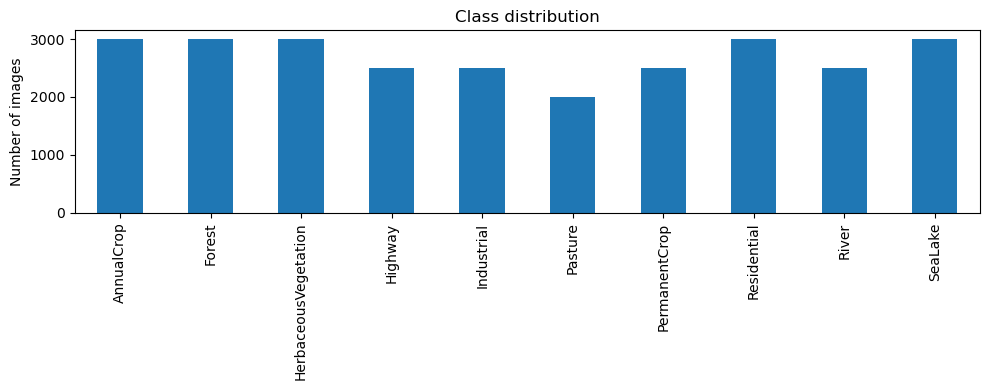

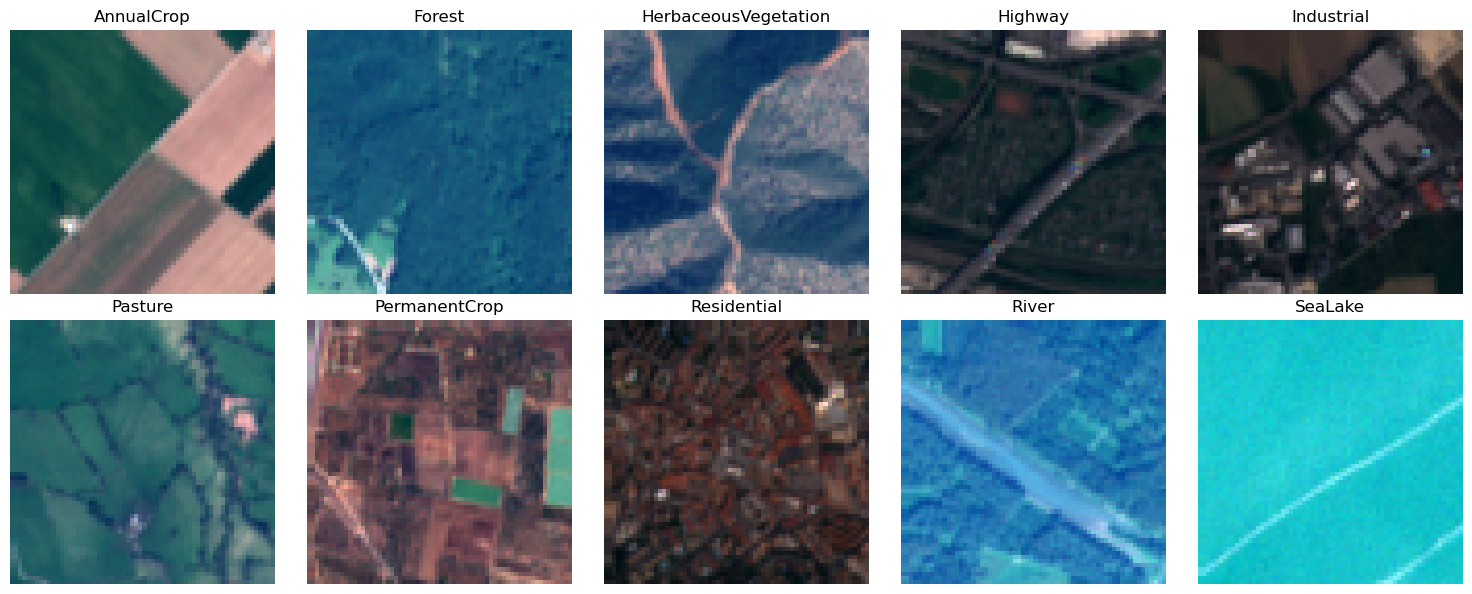

In [7]:
root = Path(r'C:\Users\MaJia\OneDrive - PennO365\文档\MUSA 650\EuroSAT_MS')

classes = sorted([p.name for p in root.iterdir() if p.is_dir()])

counts = {cls: len(list((root / cls).glob('*'))) for cls in classes}
pd.Series(counts).plot(kind='bar', figsize=(10, 4))
plt.ylabel('Number of images')
plt.title('Class distribution')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, c in zip(axes.flatten(), classes):
    folder = os.path.join(root, c)
    img_path = os.path.join(folder, random.choice(os.listdir(folder)))
    arr = tiff.imread(img_path)            
    rgb = arr[:, :, [3, 2, 1]].astype(np.float32)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
    ax.imshow(rgb)
    ax.set_title(c)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
X, y = [], []
for idx, cls in enumerate(classes):
    folder = os.path.join(root, cls)
    for f in os.listdir(folder):
        arr = tiff.imread(os.path.join(folder, f))
        X.append(arr.reshape(-1))
        y.append(idx)

X = np.stack(X).astype(np.float32)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)

In [9]:
Xg, y = [], []
for idx, cls in enumerate(classes):
    folder = os.path.join(root, cls)
    for f in os.listdir(folder):
        arr = tiff.imread(os.path.join(folder, f))
        if arr.shape[-1] == 13:
            rgb = arr[..., [3, 2, 1]].astype(np.float32)
        else:
            rgb = arr[[3, 2, 1]].transpose(1, 2, 0).astype(np.float32)
        gray = rgb2gray(rgb)
        Xg.append(gray.reshape(-1))
        y.append(idx)

Xg = np.stack(Xg).astype(np.float32)
y = np.array(y)

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    Xg, y, test_size=0.4, stratify=y, random_state=42)

## 2. Traditional Machine Learning

### 2.1 Binary Support Vector Machine

Forest vs Residential  accuracy: 0.9446  AUC: 0.9944


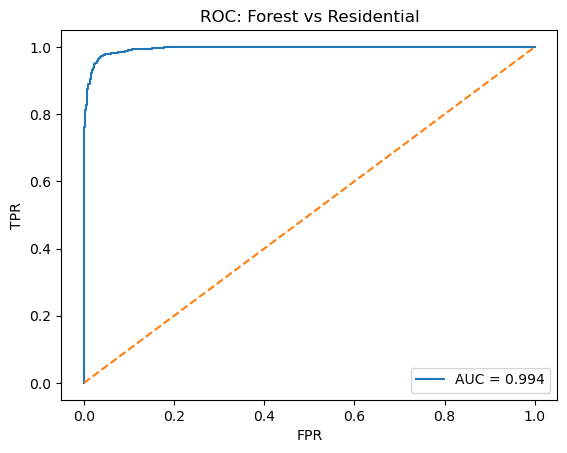

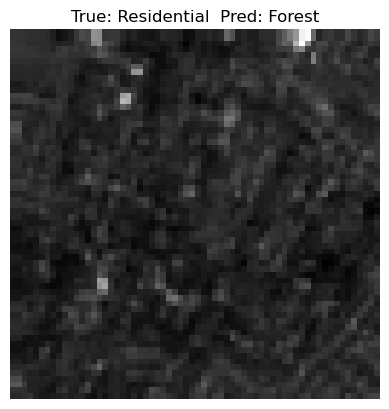

Forest vs Industrial  accuracy: 0.9964  AUC: 1.0000


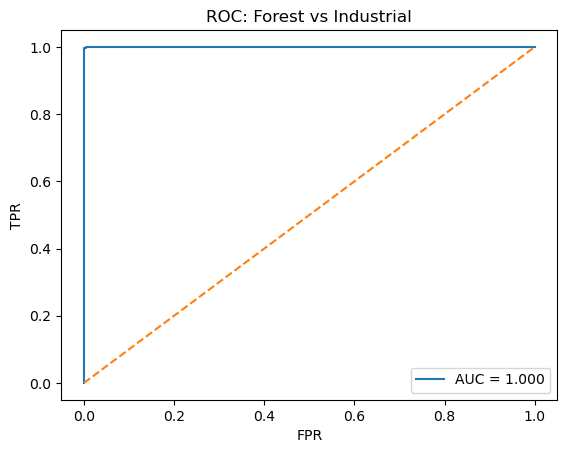

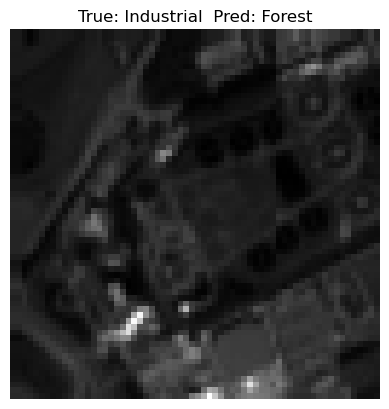

Residential vs Industrial  accuracy: 0.7223  AUC: 0.7516


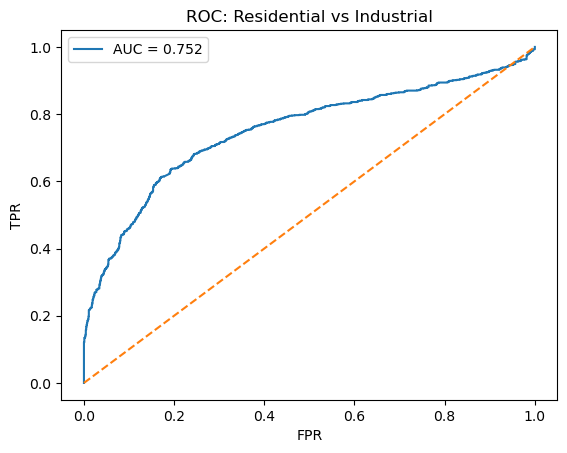

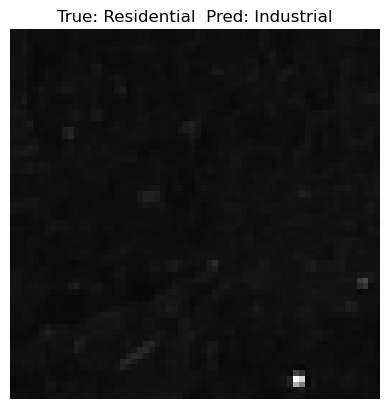

In [10]:
size = int(np.sqrt(Xg_train.shape[1]))
label_to_name = {i: n for i, n in enumerate(classes)}
name_to_label = {v: k for k, v in label_to_name.items()}

pairs = [('Forest', 'Residential'),
         ('Forest', 'Industrial'),
         ('Residential', 'Industrial')]

for a, b in pairs:
    ids = [name_to_label[a], name_to_label[b]]
    m_train = np.isin(yg_train, ids)
    m_test = np.isin(yg_test, ids)

    Xtr, ytr = Xg_train[m_train], yg_train[m_train]
    Xte, yte = Xg_test[m_test], yg_test[m_test]

    ytr_bin = (ytr == ids[1]).astype(int)
    yte_bin = (yte == ids[1]).astype(int)

    clf = SVC(kernel='linear', probability=True, random_state=42)
    clf.fit(Xtr, ytr_bin)

    prob = clf.predict_proba(Xte)[:, 1]
    pred = clf.predict(Xte)

    acc = accuracy_score(yte_bin, pred)
    fpr, tpr, _ = roc_curve(yte_bin, prob)
    roc_auc = auc(fpr, tpr)

    print(f'{a} vs {b}  accuracy: {acc:.4f}  AUC: {roc_auc:.4f}')

    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], '--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(f'ROC: {a} vs {b}')
    plt.legend()
    plt.show()

    miss = np.where(pred != yte_bin)[0]
    if len(miss):
        idx = miss[0]
        img = Xte[idx].reshape(size, size)
        true_lab = a if yte_bin[idx] == 0 else b
        pred_lab = a if pred[idx] == 0 else b
        plt.figure()
        plt.imshow(img, cmap='gray')
        plt.title(f'True: {true_lab}  Pred: {pred_lab}')
        plt.axis('off')
        plt.show()

### 2.2 Multiclass, Majority-Vote Support Vector Machine

Overall accuracy: 0.7841
Macro-average AUC: 0.9197


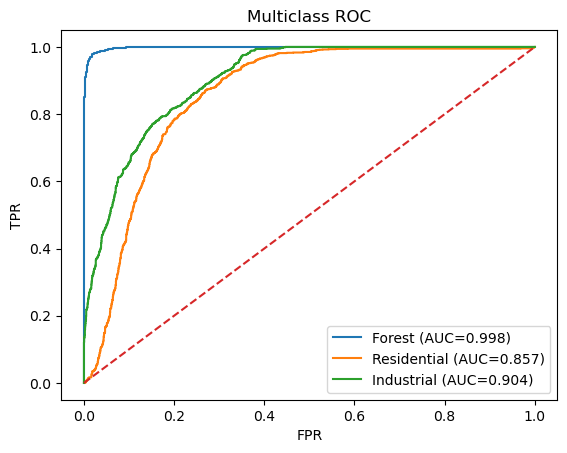

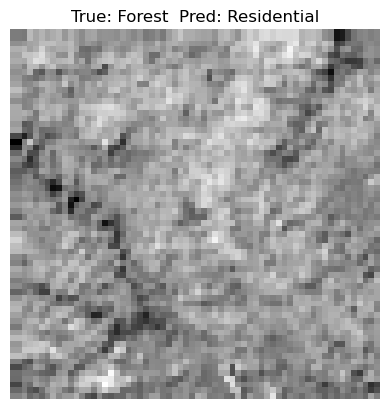

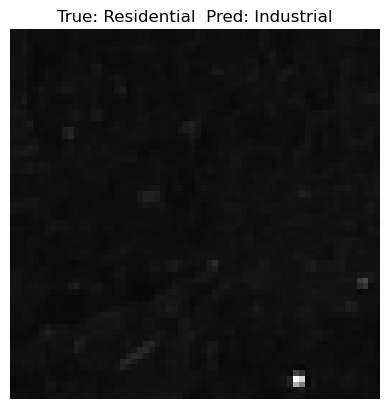

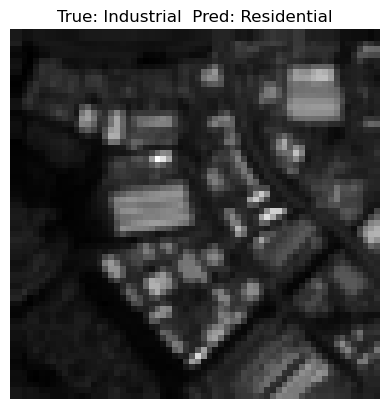

In [11]:
select_cls = ['Forest', 'Residential', 'Industrial']
sel_ids = np.array([name_to_label[c] for c in select_cls])

m_train2 = np.isin(yg_train, sel_ids)
m_test2  = np.isin(yg_test,  sel_ids)
Xtr2, ytr2 = Xg_train[m_train2], yg_train[m_train2]
Xte2, yte2 = Xg_test[m_test2],  yg_test[m_test2]

svms = {}
for a, b in pairs:
    ids = [name_to_label[a], name_to_label[b]]
    m_tr = np.isin(ytr2, ids)
    yt_bin = (ytr2[m_tr] == ids[1]).astype(int)
    clf = SVC(kernel='linear', probability=True, random_state=42)
    clf.fit(Xtr2[m_tr], yt_bin)
    svms[(a, b)] = clf

probs = np.zeros((Xte2.shape[0], 3))
votes = np.zeros((Xte2.shape[0], 3), int)

for (a, b), clf in svms.items():
    ids = [name_to_label[a], name_to_label[b]]
    pr = clf.predict_proba(Xte2)
    probs[:, np.where(sel_ids == ids[0])[0][0]] += pr[:, 0]
    probs[:, np.where(sel_ids == ids[1])[0][0]] += pr[:, 1]
    pv = clf.predict(Xte2)
    votes[np.arange(len(pv)), [np.where(sel_ids == ids[i])[0][0] for i in pv]] += 1

y_pred_idx = np.argmax(votes, axis=1)
y_pred_lbl = sel_ids[y_pred_idx]

acc = accuracy_score(yte2, y_pred_lbl)
print(f'Overall accuracy: {acc:.4f}')

probs /= 2.0
y_bin = label_binarize(yte2, classes=sel_ids)
roc_auc = roc_auc_score(y_bin, probs, average='macro', multi_class='ovr')
print(f'Macro-average AUC: {roc_auc:.4f}')

plt.figure()
for i in range(3):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f'{select_cls[i]} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Multiclass ROC'); plt.legend(); plt.show()

size = int(np.sqrt(Xg_train.shape[1]))
for cls_name, cls_id in zip(select_cls, sel_ids):
    idxs = np.where((yte2 == cls_id) & (y_pred_lbl != cls_id))[0]
    if len(idxs):
        img = Xte2[idxs[0]].reshape(size, size)
        plt.figure()
        plt.imshow(img, cmap='gray')
        plt.title(f'True: {cls_name}  Pred: {select_cls[y_pred_idx[idxs[0]]]}')
        plt.axis('off'); plt.show()

### 2.3 Multiclass Random Forest

Random Forest accuracy: 0.9097


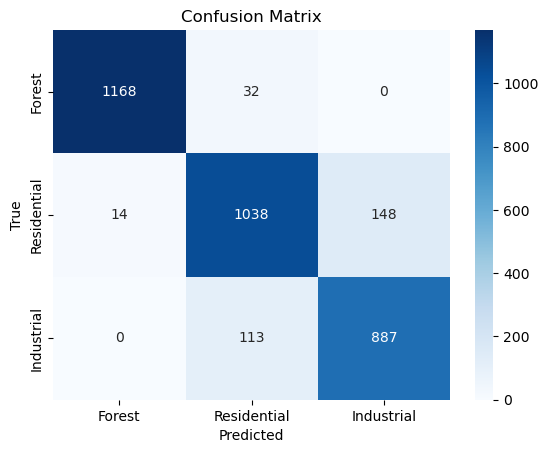

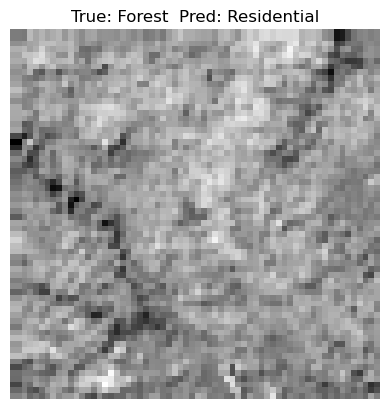

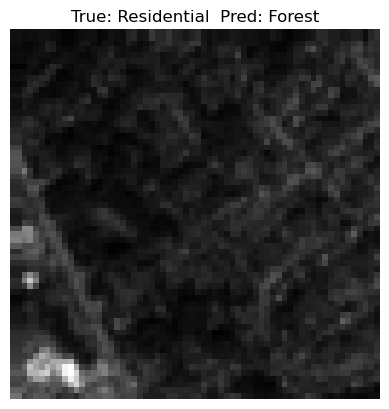

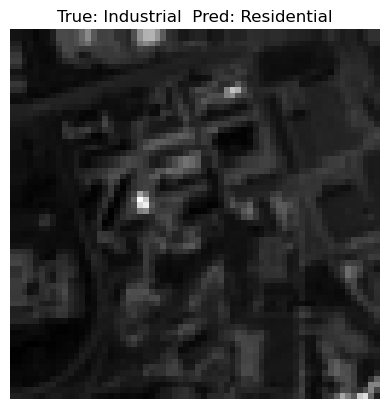

In [12]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(Xtr2, ytr2)
yp = rf.predict(Xte2)

acc = accuracy_score(yte2, yp)
print(f'Random Forest accuracy: {acc:.4f}')

cm = confusion_matrix(yte2, yp, labels=sel_ids)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=select_cls, yticklabels=select_cls)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix'); plt.show()

size = int(np.sqrt(Xg_train.shape[1]))
for cls_name, cls_id in zip(select_cls, sel_ids):
    idx = np.where((yte2 == cls_id) & (yp != cls_id))[0]
    if len(idx):
        img = Xte2[idx[0]].reshape(size, size)
        plt.figure()
        plt.imshow(img, cmap='gray')
        plt.title(f'True: {cls_name}  Pred: {select_cls[np.where(sel_ids==yp[idx[0]])[0][0]]}')
        plt.axis('off'); plt.show()

## 3. Deep Learning

### 3.1 Greyscale Images

#### 3.1.1 Model One

Epoch 1/50
64/64 - 4s - loss: 2.2715 - accuracy: 0.1236 - val_loss: 2.2471 - val_accuracy: 0.1476 - 4s/epoch - 66ms/step
Epoch 2/50
64/64 - 1s - loss: 2.2327 - accuracy: 0.1502 - val_loss: 2.2194 - val_accuracy: 0.1425 - 713ms/epoch - 11ms/step
Epoch 3/50
64/64 - 1s - loss: 2.2067 - accuracy: 0.1620 - val_loss: 2.1967 - val_accuracy: 0.1755 - 546ms/epoch - 9ms/step
Epoch 4/50
64/64 - 1s - loss: 2.1879 - accuracy: 0.1675 - val_loss: 2.1850 - val_accuracy: 0.1591 - 571ms/epoch - 9ms/step
Epoch 5/50
64/64 - 1s - loss: 2.1724 - accuracy: 0.1734 - val_loss: 2.1742 - val_accuracy: 0.1769 - 526ms/epoch - 8ms/step
Epoch 6/50
64/64 - 1s - loss: 2.1634 - accuracy: 0.1792 - val_loss: 2.1817 - val_accuracy: 0.1658 - 528ms/epoch - 8ms/step
Epoch 7/50
64/64 - 1s - loss: 2.1551 - accuracy: 0.1838 - val_loss: 2.1580 - val_accuracy: 0.1905 - 586ms/epoch - 9ms/step
Epoch 8/50
64/64 - 1s - loss: 2.1441 - accuracy: 0.2025 - val_loss: 2.1579 - val_accuracy: 0.1819 - 571ms/epoch - 9ms/step
Epoch 9/50
64/64 

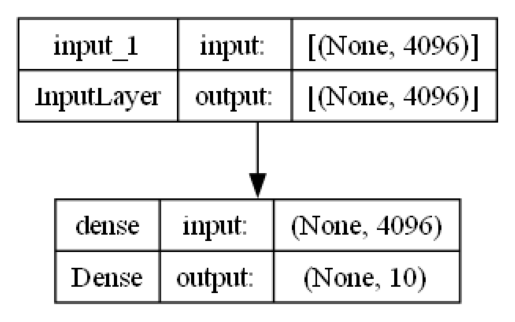

In [13]:
n_classes = len(np.unique(y))

Xg_train_n = (Xg_train.astype('float32')) / 10000.0
Xg_test_n  = (Xg_test.astype('float32'))  / 10000.0

yg_train_oh = to_categorical(yg_train, n_classes)
yg_test_oh  = to_categorical(yg_test,  n_classes)

model = Sequential([
    Input(shape=(Xg_train_n.shape[1],)),
    Dense(n_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

cb = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

hist = model.fit(Xg_train_n, yg_train_oh,
                 epochs=50,
                 batch_size=256,
                 validation_data=[Xg_test_n, yg_test_oh],
                 callbacks=[cb],
                 verbose=2)

test_loss, test_acc = model.evaluate(Xg_test_n, yg_test_oh, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')

plot_model(model, to_file='model_one.png', show_shapes=True)
plt.imshow(plt.imread('model_one.png')); plt.axis('off'); plt.show()

#### 3.1.2 Model Two

Epoch 1/50
64/64 - 1s - loss: 2.2610 - accuracy: 0.1350 - val_loss: 2.2417 - val_accuracy: 0.1431 - 1s/epoch - 21ms/step
Epoch 2/50
64/64 - 1s - loss: 2.2190 - accuracy: 0.1521 - val_loss: 2.2052 - val_accuracy: 0.1448 - 619ms/epoch - 10ms/step
Epoch 3/50
64/64 - 0s - loss: 2.1896 - accuracy: 0.1572 - val_loss: 2.1847 - val_accuracy: 0.1729 - 455ms/epoch - 7ms/step
Epoch 4/50
64/64 - 0s - loss: 2.1738 - accuracy: 0.1592 - val_loss: 2.1863 - val_accuracy: 0.1582 - 476ms/epoch - 7ms/step
Epoch 5/50
64/64 - 1s - loss: 2.1607 - accuracy: 0.1770 - val_loss: 2.1689 - val_accuracy: 0.1427 - 508ms/epoch - 8ms/step
Epoch 6/50
64/64 - 0s - loss: 2.1432 - accuracy: 0.1830 - val_loss: 2.1518 - val_accuracy: 0.2108 - 480ms/epoch - 7ms/step
Epoch 7/50
64/64 - 0s - loss: 2.1290 - accuracy: 0.2044 - val_loss: 2.1300 - val_accuracy: 0.2481 - 473ms/epoch - 7ms/step
Epoch 8/50
64/64 - 0s - loss: 2.1126 - accuracy: 0.2324 - val_loss: 2.1240 - val_accuracy: 0.2167 - 447ms/epoch - 7ms/step
Epoch 9/50
64/64 

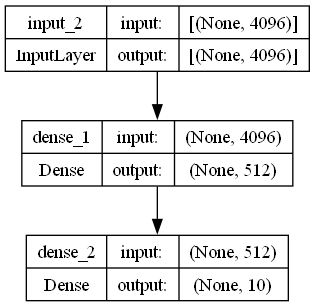

In [14]:
model2 = Sequential([
    Input(shape=(Xg_train_n.shape[1],)),
    Dense(512, activation='relu'),
    Dense(n_classes, activation='softmax')
])

opt = Adam(                             
    learning_rate=2e-4,                 
    beta_1=0.9,                         
    beta_2=0.999,                       
    epsilon=1e-7,                       
    amsgrad=False                       
)

model2.compile(optimizer=opt,
               loss='categorical_crossentropy',
               metrics=['accuracy'])

early = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

model2.fit(Xg_train_n, yg_train_oh,
           epochs=50,
           batch_size=256,
           validation_data=[Xg_test_n, yg_test_oh],
           callbacks=[early],
           verbose=2)

test_loss2, test_acc2 = model2.evaluate(Xg_test_n, yg_test_oh, verbose=0)
print(f'Test accuracy (model two): {test_acc2:.4f}')

plot_model(model2, to_file='model_two.png', show_shapes=True)

Adding an additional hidden layer has largely increased the model's accuracy on test datasets, from 19% to 32%. Instead of mapping individual pixels, the new layer helps the network learn patterns by combining groups of pixels into more abstract features. Additionally, using a ReLU activation introduces non-linearity, which lets the model learn more flexible decision boundaries.

#### 3.1.3 Model Three

Epoch 1/80
64/64 - 1s - loss: 2.2793 - accuracy: 0.1174 - val_loss: 2.2141 - val_accuracy: 0.1355 - 1s/epoch - 22ms/step
Epoch 2/80
64/64 - 1s - loss: 2.1640 - accuracy: 0.1875 - val_loss: 2.0925 - val_accuracy: 0.1894 - 602ms/epoch - 9ms/step
Epoch 3/80
64/64 - 1s - loss: 1.9964 - accuracy: 0.2687 - val_loss: 1.8825 - val_accuracy: 0.2958 - 635ms/epoch - 10ms/step
Epoch 4/80
64/64 - 1s - loss: 1.8558 - accuracy: 0.2947 - val_loss: 1.8454 - val_accuracy: 0.2999 - 538ms/epoch - 8ms/step
Epoch 5/80
64/64 - 1s - loss: 1.7787 - accuracy: 0.3176 - val_loss: 1.7362 - val_accuracy: 0.3372 - 655ms/epoch - 10ms/step
Epoch 6/80
64/64 - 1s - loss: 1.7754 - accuracy: 0.3301 - val_loss: 1.8176 - val_accuracy: 0.2971 - 656ms/epoch - 10ms/step
Epoch 7/80
64/64 - 1s - loss: 1.7165 - accuracy: 0.3507 - val_loss: 1.7073 - val_accuracy: 0.3469 - 656ms/epoch - 10ms/step
Epoch 8/80
64/64 - 1s - loss: 1.7128 - accuracy: 0.3490 - val_loss: 1.6980 - val_accuracy: 0.3472 - 574ms/epoch - 9ms/step
Epoch 9/80
64/

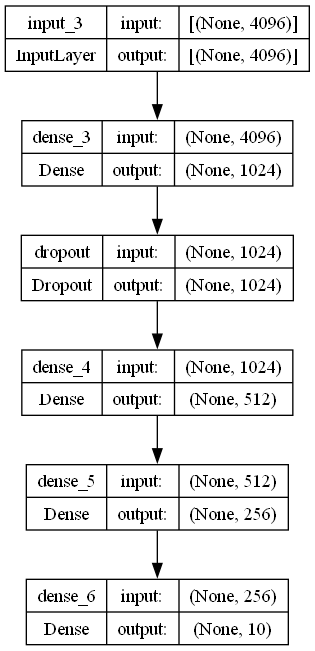

In [15]:
model3 = Sequential([
    Input(shape=(Xg_train_n.shape[1],)),
    Dense(1024, activation='relu'),
    Dropout(0.1),               
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(n_classes, activation='softmax')
])

model3.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

early = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)

model3.fit(Xg_train_n, yg_train_oh,
           epochs=80,
           batch_size=256,
           validation_data=[Xg_test_n, yg_test_oh],
           callbacks=[early],
           verbose=2)

test_loss3, test_acc3 = model3.evaluate(Xg_test_n, yg_test_oh, verbose=0)
print(f'Test accuracy (model three): {test_acc3:.4f}')

plot_model(model3, to_file='model_three.png', show_shapes=True)

The dropout layer in our case tends to effect the model negatively in reducing the test accuracy, especially when dropout rate is set to 0.3-0.5. Generally, dropout layers can be effective when the original model is overfitting and giving too much weight to certain nodes. However, in our experiment, the baseline network was already struggling to learn enough discriminative features, so zeroing out additional neurons would just remove meaningful information the model needed.

#### 3.1.4 Model Comparison

In [16]:
model.summary()
model2.summary()
model3.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                40970     
                                                                 
Total params: 40,970
Trainable params: 40,970
Non-trainable params: 0
_________________________________________________________________
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 512)               2097664   
                                                                 
 dense_2 (Dense)             (None, 10)                5130      
                                                                 
Total params: 2,102,794
Trainable params: 2,102,794
Non-trainable params: 0
_________________________________________________________________
Model: "sequential_2

The third model has most parameters by far compared to the first and second model. The first model uses one fully connected output layer with the input layer, having 40,970 parameters in total. The second model adds one hidden layer of 512 nodes, leading it to have about 50 times of model 1's parameters. The third model uses three dense layers and has about 120 times of model 1's paramsters.

In terms of accuracy on test dataset, model 3 is the "best" model with a 40%+ prediction accuracy, as compared to model 1's 19.1% and model 2's 32.6%. The higher accuracy is probably caused by the network's ability to extract more complex and abstract patterns, through its additional layers and non-linear transformations.

As we increased the number of training epochs across models, performance usually improved, but only up to a point. Model 1 plateaued fast and never got very far, which makes sense since it only had a linear classifier. Model 2 improved steadily over the first 15 to 20 epochs before leveling off. Model 3 took longer to train but kept improving for a while, especially once it had enough layers and the right dropout configuration.

### 3.2 RGB Images

#### 3.2.1 Model Four

In [17]:
Xrgb, yrgb = [], []
for idx, cls in enumerate(classes):
    folder = os.path.join(root, cls)
    for f in os.listdir(folder):
        arr = tiff.imread(os.path.join(folder, f))        
        if arr.shape[0] == 13:                            
            rgb = arr[[3, 2, 1]].transpose(1, 2, 0)
        else:                                             
            rgb = arr[:, :, [3, 2, 1]]
        Xrgb.append(rgb.astype(np.float32) / 10000.0)    
        yrgb.append(idx)

Xrgb = np.stack(Xrgb)                                   
yrgb = np.array(yrgb)

Xrgb_train, Xrgb_test, yrgb_train, yrgb_test = train_test_split(
    Xrgb, yrgb, test_size=0.4, stratify=yrgb, random_state=42)

Epoch 1/40
507/507 - 8s - loss: 1.5676 - accuracy: 0.4089 - val_loss: 1.1922 - val_accuracy: 0.5748 - 8s/epoch - 17ms/step
Epoch 2/40
507/507 - 3s - loss: 1.1771 - accuracy: 0.5694 - val_loss: 0.9515 - val_accuracy: 0.6497 - 3s/epoch - 6ms/step
Epoch 3/40
507/507 - 4s - loss: 1.0067 - accuracy: 0.6426 - val_loss: 0.8688 - val_accuracy: 0.6812 - 4s/epoch - 7ms/step
Epoch 4/40
507/507 - 3s - loss: 0.9243 - accuracy: 0.6702 - val_loss: 0.7838 - val_accuracy: 0.7190 - 3s/epoch - 7ms/step
Epoch 5/40
507/507 - 4s - loss: 0.8502 - accuracy: 0.6958 - val_loss: 0.6848 - val_accuracy: 0.7553 - 4s/epoch - 7ms/step
Epoch 6/40
507/507 - 3s - loss: 0.7783 - accuracy: 0.7262 - val_loss: 0.7323 - val_accuracy: 0.7243 - 3s/epoch - 6ms/step
Epoch 7/40
507/507 - 3s - loss: 0.7243 - accuracy: 0.7425 - val_loss: 0.6767 - val_accuracy: 0.7693 - 3s/epoch - 7ms/step
Epoch 8/40
507/507 - 4s - loss: 0.6838 - accuracy: 0.7586 - val_loss: 0.6208 - val_accuracy: 0.7812 - 4s/epoch - 7ms/step
Epoch 9/40
507/507 - 4s

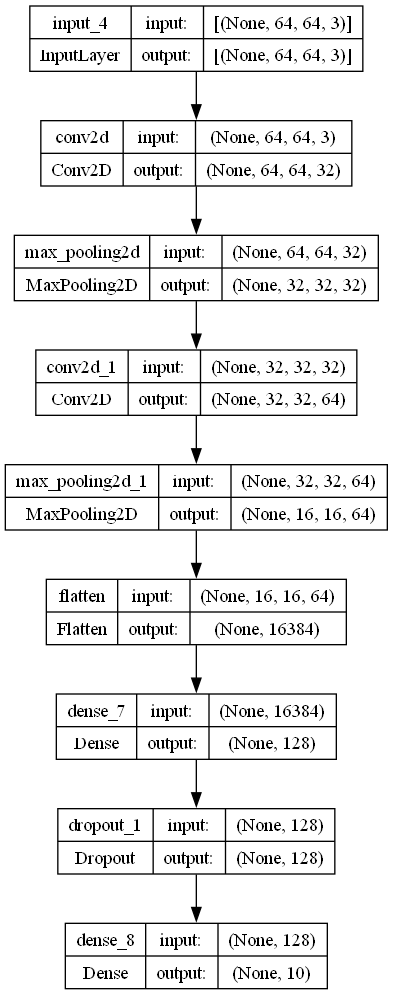

In [18]:
n_classes = len(np.unique(y))

Xrgb_train_n = (Xrgb_train.astype('float32')) 
Xrgb_test_n  = (Xrgb_test.astype('float32'))  

yrgb_train_oh = to_categorical(yrgb_train, n_classes)
yrgb_test_oh  = to_categorical(yrgb_test,  n_classes)

model4 = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    #Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    #Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(n_classes, activation='softmax')
])

model4.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

early = EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True)

model4.fit(Xrgb_train_n, yrgb_train_oh,
           epochs=40,
           batch_size=32,
           validation_data=[Xrgb_test_n, yrgb_test_oh],
           callbacks=[early],
           verbose=2)

test_loss4, test_acc4 = model4.evaluate(Xrgb_test_n, yrgb_test_oh, batch_size=32, verbose=0)
print(f'Test accuracy (model four): {test_acc4:.4f}')

plot_model(model4, to_file='model_four.png', show_shapes=True)

The CNN model improves greatly in prediction accuracy, raising from model 3's 40%+ to 80%+, thus making it the "best" model so far. The difference in training time is not strongly preceived between initial training epochs, but ideally training with CNN would take longer training time than training with flattened layers.

The CNN model preserves the spatial information of pixels by extracting and learning a small group of pixels at a time, and thus is able to learn features that appear together or appear in similar places for a certain class of image. At the same time, fully connected models are unable to tell the spatial relationships between pixels, which might lead to failure in recognizing important classification features. CNNs generally take more compute resources because they are learning and predicting with 3D tensors, which are usually larger in data volume. 

#### 3.2.2 Model Five

Epoch 1/60
507/507 - 19s - loss: 1.0940 - accuracy: 0.6223 - val_loss: 3.3258 - val_accuracy: 0.2679 - lr: 0.0010 - 19s/epoch - 37ms/step
Epoch 2/60
507/507 - 16s - loss: 0.6892 - accuracy: 0.7666 - val_loss: 1.4126 - val_accuracy: 0.6317 - lr: 0.0010 - 16s/epoch - 31ms/step
Epoch 3/60
507/507 - 16s - loss: 0.5104 - accuracy: 0.8307 - val_loss: 2.4662 - val_accuracy: 0.5189 - lr: 0.0010 - 16s/epoch - 32ms/step
Epoch 4/60
507/507 - 16s - loss: 0.4139 - accuracy: 0.8665 - val_loss: 0.5470 - val_accuracy: 0.8250 - lr: 0.0010 - 16s/epoch - 32ms/step
Epoch 5/60
507/507 - 17s - loss: 0.3421 - accuracy: 0.8843 - val_loss: 6.4824 - val_accuracy: 0.3512 - lr: 0.0010 - 17s/epoch - 33ms/step
Epoch 6/60
507/507 - 17s - loss: 0.3365 - accuracy: 0.8910 - val_loss: 3.5030 - val_accuracy: 0.4506 - lr: 0.0010 - 17s/epoch - 33ms/step
Epoch 7/60

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
507/507 - 17s - loss: 0.2969 - accuracy: 0.9012 - val_loss: 1.2370 - val_accuracy: 0

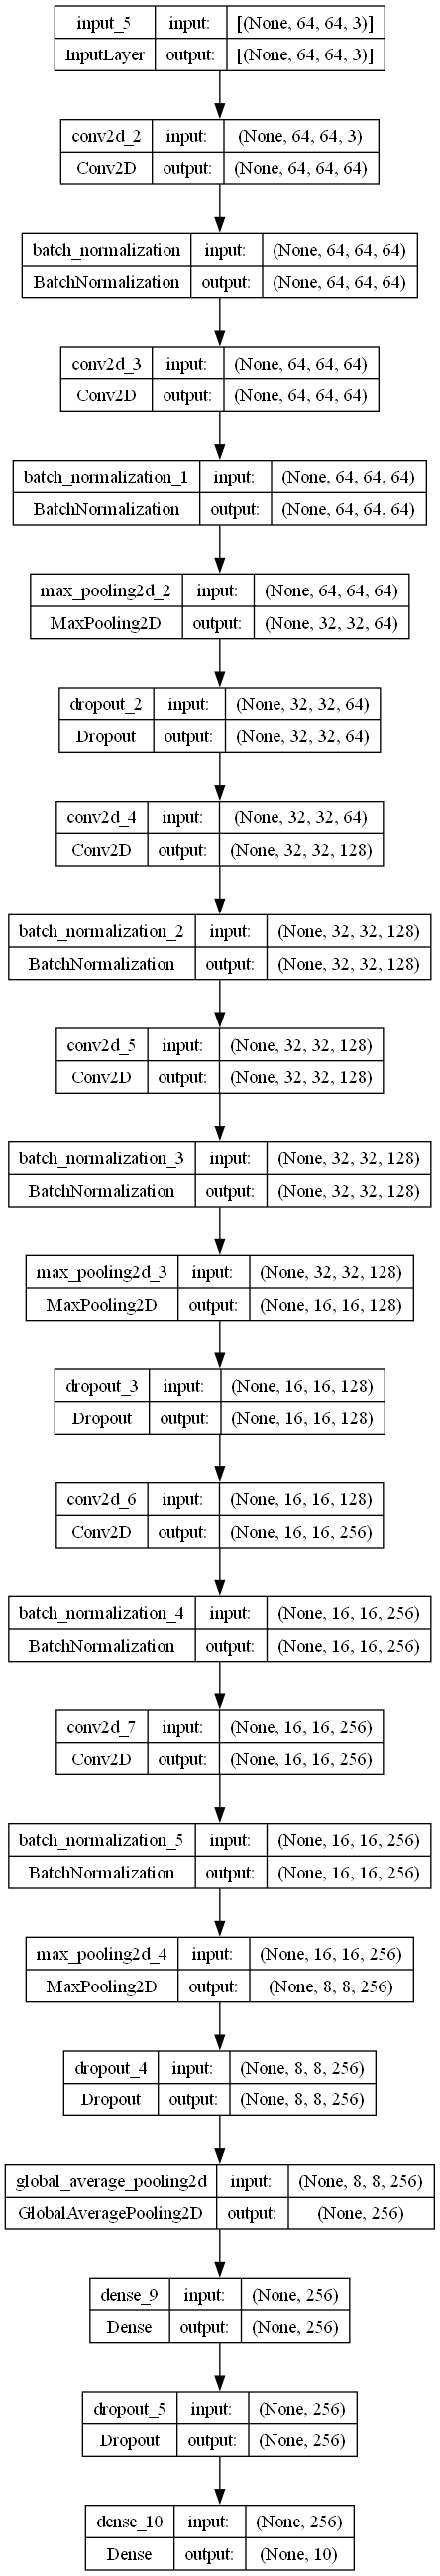

In [19]:
model5 = Sequential([
    Input(shape=(64, 64, 3)),

    Conv2D(64, 3, padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(64, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(128, 3, padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(128, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(256, 3, padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(256, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),

    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(n_classes, activation="softmax")
])

model5.compile(optimizer="adam",
               loss="categorical_crossentropy",
               metrics=["accuracy"])

callbacks = [
    ReduceLROnPlateau(monitor="val_accuracy", factor=0.5,
                      patience=3, min_lr=1e-5, verbose=1),
    EarlyStopping(monitor="val_accuracy", patience=8,
                  restore_best_weights=True, verbose=1)
]

model5.fit(Xrgb_train_n, yrgb_train_oh,
           epochs=60,
           batch_size=32,
           validation_data=[Xrgb_test_n, yrgb_test_oh],
           callbacks=callbacks,
           verbose=2)

test_loss5, test_acc5 = model5.evaluate(
    Xrgb_test_n, yrgb_test_oh,
    batch_size=32,           
    verbose=0
)
print(f"Test accuracy (model five): {test_acc5:.4f}")

plot_model(model5, to_file="model_five.png", show_shapes=True)

A series of tools/techniques are used to establish the "best" model so far. First of all, an additional convolution block of 256 filters is used on top of the two existing blocks (64 and 128 filters). This enables model to learn a potentially deeper structural hierarchy existing in images. Inside each block, the conv2D() function are called twice, to allow the network to learn more complex functions by doubling the non-linenarity. A BatchNormalization() function is called after each conv2D() function, to ensure values fall within a reasonable, learnable range.

GlobalAveragePooling2D() is used instead of flatten() before the final dense layer to better preserve the spatial context. Additionally, different levels of dropout layers are applied after each block. The smaller dropout rate in initial blocks keep the low-level features intact, while heavier dropout at later stages prevents model from over-fitting.

Outside of the model, early stopping functions are used to adjust model learning rate and determine optimal training epochs. When prediction accuracy has stale for eight epochs, the training loop would be ended; when it stops improving for three epochs, the ReduceLROnPlateau() function will reduce current learning rate in half to ensure the training loop not being accidently ended early.

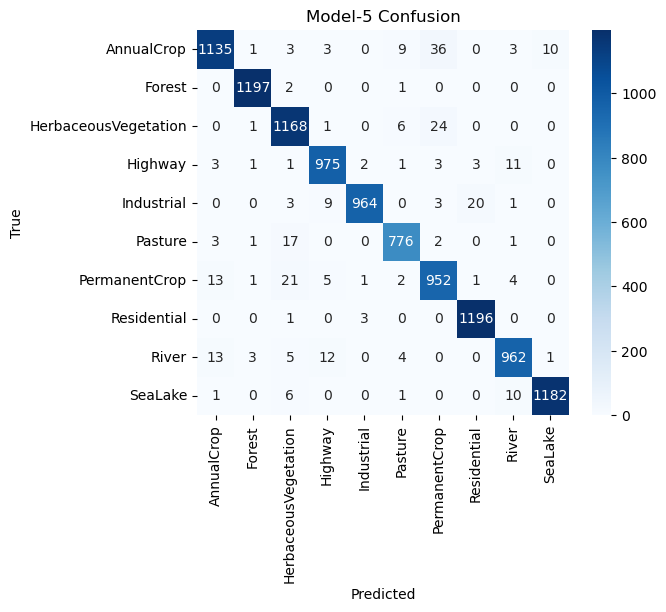

Two hardest classes:
AnnualCrop — 65 errors
PermanentCrop — 48 errors


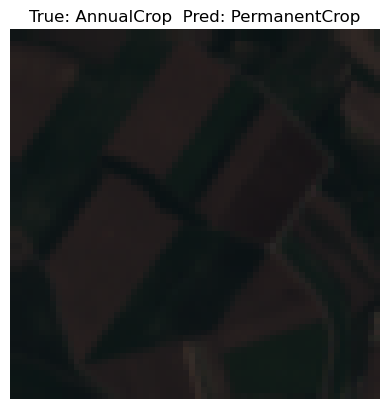

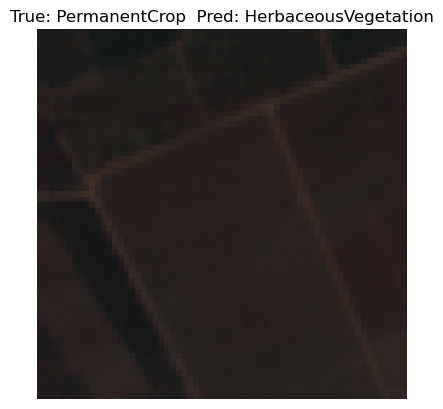

In [20]:
y_pred_probs = model5.predict(Xrgb_test_n, batch_size=128, verbose=0)
y_pred_lbl   = np.argmax(y_pred_probs, axis=1)
y_true_lbl   = yrgb_test                       

cm = confusion_matrix(y_true_lbl, y_pred_lbl, labels=np.arange(n_classes))

errors_per_class = cm.sum(axis=1) - np.diag(cm)  
worst_two = errors_per_class.argsort()[-2:][::-1] 

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Model‑5 Confusion'); plt.show()

print("Two hardest classes:")
for cid in worst_two:
    print(f"{classes[cid]} — {errors_per_class[cid]} errors")

for cid in worst_two:
    mis_idx = np.where((y_true_lbl == cid) & (y_pred_lbl != cid))[0]
    if mis_idx.size:
        i = mis_idx[0]
        plt.figure()
        plt.imshow((Xrgb_test_n[i]*255).astype('uint8'))
        plt.title(f"True: {classes[cid]}  Pred: {classes[y_pred_lbl[i]]}")
        plt.axis('off')
        plt.show()

The two classes with the highest labeling error are permanent cropland and river. Under a low resolution (64*64), these areas can lack decisive characteristics and appear to be similar with generic vegetated areas, with matching color hues and patterns. In the two visualized misclassified examples above, one permanent crop area is mistakenly classified as herbaceous vegetated area, while an annual crop area is mistakenly classified as permanent crop area. Using higher resolution and multi-spectral band image may help to solve the problem.

In [21]:
tf.keras.backend.clear_session()
gc.collect()

15752

### 3.3 Multispectral Images

In [26]:
Xms, yms = [], []
for idx, cls in enumerate(classes):
    folder = os.path.join(root, cls)
    for f in os.listdir(folder):
        arr = tiff.imread(os.path.join(folder, f))    
        if arr.shape[0] == 13:                            
            rgb = arr[[3, 2, 1, 7, 10]].transpose(1, 2, 0)
        else:                                             
            rgb = arr[:, :, [3, 2, 1, 7, 10]]            
        Xms.append(rgb.astype(np.float32))
        yms.append(idx)

Xms = np.stack(Xms)       
yms = np.array(yms)

Xms_train, Xms_test, yms_train, yms_test = train_test_split(
    Xms, yms, test_size=0.4, stratify=yms, random_state=42)

Xms_train_n = Xms_train / 10000.0
Xms_test_n  = Xms_test  / 10000.0
yms_train_oh = to_categorical(yms_train, n_classes)
yms_test_oh  = to_categorical(yms_test,  n_classes)

In [27]:
model_ms = Sequential([
    Input(shape=(64, 64, 5)),

    Conv2D(64, 3, padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(64, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(128, 3, padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(128, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(256, 3, padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(256, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),

    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(n_classes, activation="softmax")
])

model_ms.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    ReduceLROnPlateau(monitor="val_accuracy", factor=0.5,
                      patience=3, min_lr=1e-5, verbose=1),
    EarlyStopping(monitor="val_accuracy", patience=8,
                  restore_best_weights=True, verbose=1)
]

model_ms.fit(
    Xms_train_n, yms_train_oh,
    epochs=60,
    batch_size=32,
    validation_data=(Xms_test_n, yms_test_oh),
    callbacks=callbacks,
    verbose=2
)

test_loss6, test_acc6 = model_ms.evaluate(
    Xms_test_n, yms_test_oh,
    batch_size=32, verbose=0
)
print(f"Multispectral CNN test accuracy: {test_acc6:.4f}")
print(f"RGB CNN test accuracy was:    {test_acc5:.4f}")

Epoch 1/60
507/507 - 17s - loss: 0.8137 - accuracy: 0.7227 - val_loss: 3.1166 - val_accuracy: 0.3599 - lr: 0.0010 - 17s/epoch - 34ms/step
Epoch 2/60
507/507 - 14s - loss: 0.4741 - accuracy: 0.8439 - val_loss: 0.8378 - val_accuracy: 0.7406 - lr: 0.0010 - 14s/epoch - 28ms/step
Epoch 3/60
507/507 - 14s - loss: 0.3444 - accuracy: 0.8869 - val_loss: 0.7476 - val_accuracy: 0.7930 - lr: 0.0010 - 14s/epoch - 28ms/step
Epoch 4/60
507/507 - 14s - loss: 0.3033 - accuracy: 0.9025 - val_loss: 1.6004 - val_accuracy: 0.6443 - lr: 0.0010 - 14s/epoch - 29ms/step
Epoch 5/60
507/507 - 15s - loss: 0.2708 - accuracy: 0.9104 - val_loss: 0.4388 - val_accuracy: 0.8643 - lr: 0.0010 - 15s/epoch - 30ms/step
Epoch 6/60
507/507 - 16s - loss: 0.2381 - accuracy: 0.9217 - val_loss: 1.4266 - val_accuracy: 0.6998 - lr: 0.0010 - 16s/epoch - 32ms/step
Epoch 7/60
507/507 - 16s - loss: 0.2075 - accuracy: 0.9322 - val_loss: 0.2629 - val_accuracy: 0.9216 - lr: 0.0010 - 16s/epoch - 32ms/step
Epoch 8/60
507/507 - 18s - loss: 0

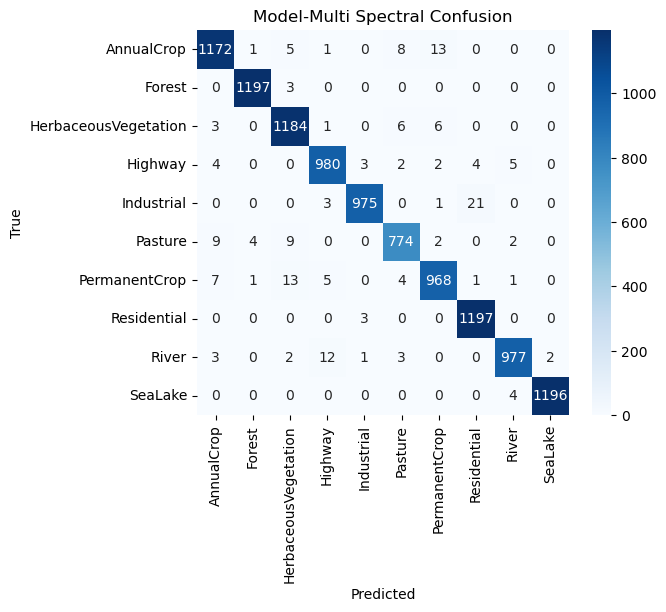

Two hardest classes:
PermanentCrop — 32 errors
AnnualCrop — 28 errors


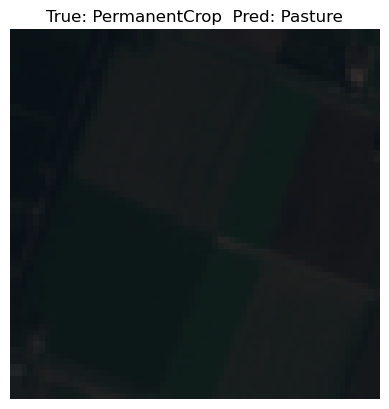

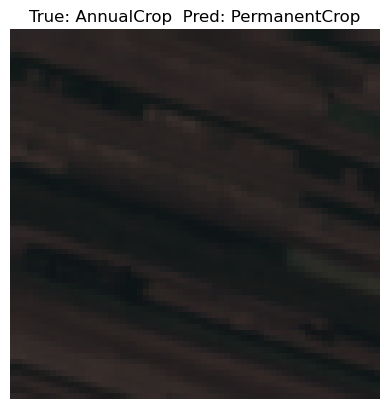

In [30]:
y_pred_probs2 = model_ms.predict(Xms_test_n, batch_size=128, verbose=0)
y_pred_lbl2   = np.argmax(y_pred_probs2, axis=1)
y_true_lbl2   = yms_test                       

cm = confusion_matrix(y_true_lbl2, y_pred_lbl2, labels=np.arange(n_classes))

errors_per_class = cm.sum(axis=1) - np.diag(cm)  
worst_two = errors_per_class.argsort()[-2:][::-1] 

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Model‑Multi Spectral Confusion'); plt.show()

print("Two hardest classes:")
for cid in worst_two:
    print(f"{classes[cid]} — {errors_per_class[cid]} errors")

for cid in worst_two:
    mis_idx = np.where((y_true_lbl2 == cid) & (y_pred_lbl2 != cid))[0]
    if mis_idx.size:
        i = mis_idx[0]
        plt.figure()
        plt.imshow((Xms_test_n[..., :3][i]*255).astype('uint8'))
        plt.title(f"True: {classes[cid]}  Pred: {classes[y_pred_lbl2[i]]}")
        plt.axis('off')
        plt.show()

Adding the extra NIR and SWIR1 bands gives a small but consistent boost in accuracy. NIR helps the model pick up on things like vegetation, biomass and shoreline edges. SWIR1 responds to moisture in soil and plants, so it makes it easier to tell different types of vegetation apart.

## 4. Reflection Questions

From these experiments, it seems that model depth played a critical role in performance: increasing the number of convolutional blocks up to four or five consistently yielded higher accuracy, as each additional block facilitated the learning of deeper feature hierarchies. Within each block, the use of two consecutive Conv2D layers was shown to enhance representational capacity by introducing additional non-linear transformations. It was also determined that applying BatchNormalization after every convolution stabilized activation distributions and improved overall training accuracy.

Furthermore, the experiments with dropout layers proved them to be effective only in architectures that already exhibited strong baseline performance; in under-fitting models, dropout was observed to remove essential information and decrease accuracy. Finally, the incorporation of an early-stopping criterion enabled the detection of model training plateaued optimal points, thereby preventing unnecessary epochs and reducing the risk of over-fitting.

As the number of training epochs was increased, training loss was seen to decrease and training accuracy to rise, but validation accuracy often leveled off after a certain point. Without an early-stopping criterionr, further epochs would have led to over-fitting or unnecessary compute time.

Memory limitations were encountered when loading and training for large multispectral datasets, which necessitated the use of batched evaluation. Model sessions were periodically cleared to prevent excess memory usage when experimenting with multiple architectures in a single notebook.

The same principles applied in this report, including considerations in layer stacking, use of normalization and dropout, and monitored training with callbacks, can be directly applied to other image-based deep learning tasks, such as detecting land cover change or mapping flood extent, to achieve efficient and robust model performance. 

## Citation

ChatGPT (o3 version) is used in assistance to produce code for this assignment.